In [ ]:
# Install required libaries
!pip install nrclex
!pip install wordcloud
!pip install nltk

In [ ]:
# Import core data analysis libaries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from nrclex import NRCLex

In [ ]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Load fake and real news datasets from zipped CSV files
fake_df = pd.read_csv('Fake.csv.zip')
true_df = pd.read_csv('True.csv.zip')

In [ ]:
# Keep only the title/headline column for this project
fake_df = fake_df[['title']]
true_df = true_df[['title']]

In [ ]:
# Create binary labels
# 1 = fake headline
# 0 = real headline

fake_df['label'] = 1
true_df['label'] = 0

In [ ]:
# Combine fake and real headlines into one dataframe
df = pd.concat([fake_df, true_df], ignore_index=True)

print(df.head())
print(df['label'].value_counts())

                                               title  label
0   Donald Trump Sends Out Embarrassing New Year’...      1
1   Drunk Bragging Trump Staffer Started Russian ...      1
2   Sheriff David Clarke Becomes An Internet Joke...      1
3   Trump Is So Obsessed He Even Has Obama’s Name...      1
4   Pope Francis Just Called Out Donald Trump Dur...      1
label
1    23481
0    21417
Name: count, dtype: int64


In [ ]:
# Create a set of English stopwords
stop_words = set(stopwords.words('english'))

# Function to clean and preprocess headline text
def clean_text(text):
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+', '', text)

    # remove punctuation/numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

In [ ]:
# Apply text cleaning function to all headlines
df['clean_title'] = df['title'].apply(clean_text)

print(df[['title', 'clean_title']].head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                         clean_title  
0  donald trump sends embarrassing new years eve ...  
1  drunk bragging trump staffer started russian c...  
2  sheriff david clarke becomes internet joke thr...  
3  trump obsessed even obamas name coded website ...  
4  pope francis called donald trump christmas speech  


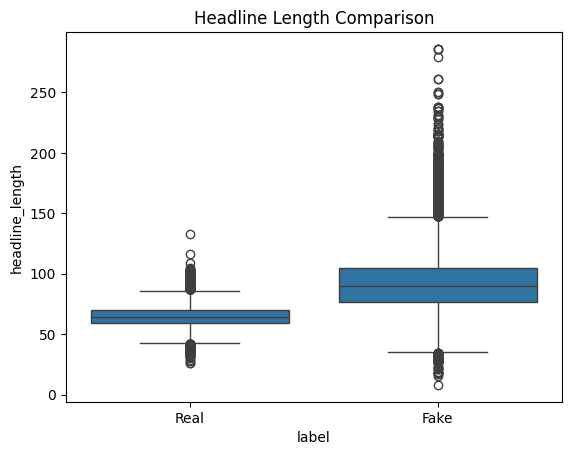

In [ ]:
# Calculate headline length using the original title text
df['headline_length'] = df['title'].apply(len)

# Create boxplot comparing headline lengths by label
sns.boxplot(x='label', y='headline_length', data=df)

plt.xticks([0,1], ['Real', 'Fake'])
plt.title('Headline Length Comparison')
plt.show()

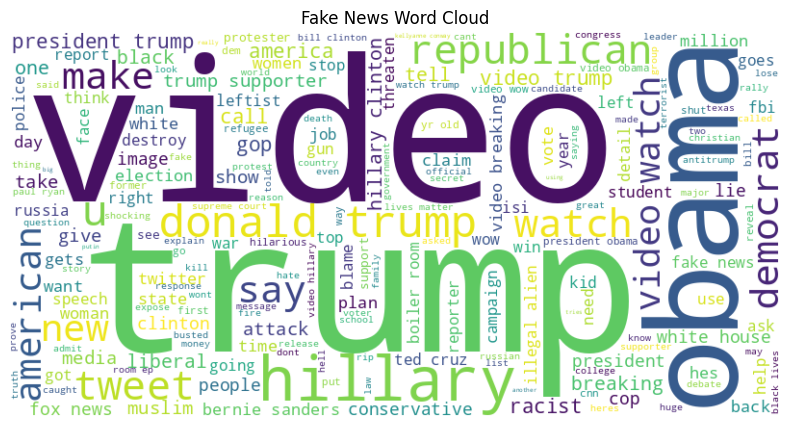

In [ ]:
# Create word cloud for fake headlines
fake_words = " ".join(df[df['label'] == 1]['clean_title'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Fake News Word Cloud')
plt.show()

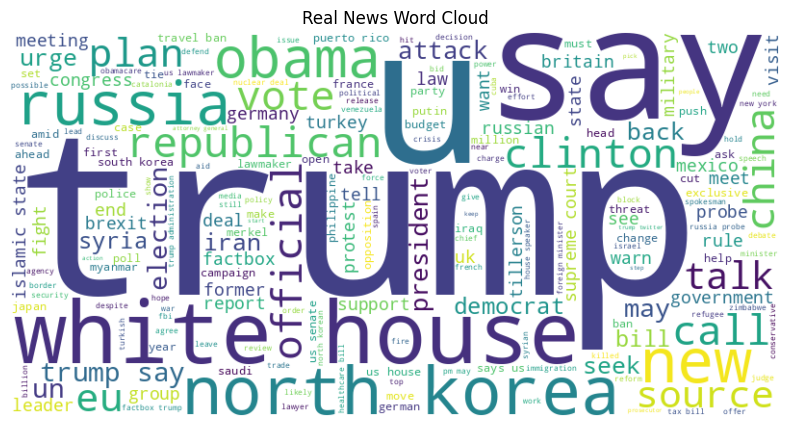

In [ ]:
# Create word cloud for real headlines
real_words = " ".join(df[df['label'] == 0]['clean_title'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(real_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Real News Word Cloud')
plt.show()

In [ ]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['title'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

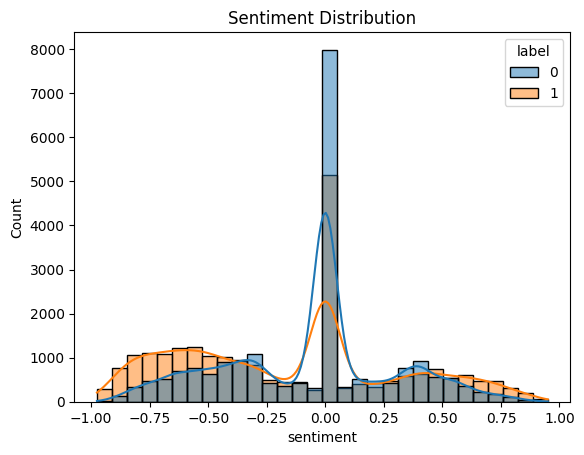

In [ ]:
# Visualize sentiment distribution by headline label
sns.histplot(
    data=df,
    x='sentiment',
    hue='label',
    kde=True,
    bins=30
)

plt.title('Sentiment Distribution')
plt.show()

In [ ]:
# Calculate mean and standard deviation of sentiment by label
df.groupby('label')['sentiment'].agg(['mean', 'std'])

,mean,std
label,,
0,-0.067406,0.363021
1,-0.160665,0.470835


In [ ]:
# Load NRC Emotion Lexicon file
import pandas as pd

nrc = pd.read_csv(
    'NRC-Emotion-Lexicon-Wordlevel-v0.92.txt',
    sep='\t',
    header=None,
    names=['word', 'emotion', 'association']
)

print(nrc.head())

    word       emotion  association
0  aback         anger            0
1  aback  anticipation            0
2  aback       disgust            0
3  aback          fear            0
4  aback           joy            0


In [ ]:
# Keep only rows where the emotion association exists
nrc = nrc[nrc['association'] == 1]

In [ ]:
# Create dictionary mapping words to emotions
emotion_dict = {}

for _, row in nrc.iterrows():
    word = row['word']
    emotion = row['emotion']

    if word not in emotion_dict:
        emotion_dict[word] = []

    emotion_dict[word].append(emotion)

In [ ]:
# Define emotion categories used in analysis
emotion_categories = [
    'anger',
    'fear',
    'joy',
    'sadness',
    'trust',
    'surprise',
    'anticipation',
    'disgust'
]

# Function to count emotion words in headlines
def extract_emotions(text):

    counts = {emotion: 0 for emotion in emotion_categories}

    words = text.lower().split()

    for word in words:

        if word in emotion_dict:

            for emotion in emotion_dict[word]:

                if emotion in counts:
                    counts[emotion] += 1

    return counts

In [ ]:
# Apply emotion extraction to cleaned headlines
emotion_data = df['clean_title'].apply(extract_emotions)

emotion_df = pd.json_normalize(emotion_data)

df = pd.concat([df, emotion_df], axis=1)

print(df.head())

                                               title  label  \
0   Donald Trump Sends Out Embarrassing New Year’...      1   
1   Drunk Bragging Trump Staffer Started Russian ...      1   
2   Sheriff David Clarke Becomes An Internet Joke...      1   
3   Trump Is So Obsessed He Even Has Obama’s Name...      1   
4   Pope Francis Just Called Out Donald Trump Dur...      1   

                                         clean_title  headline_length  \
0  donald trump sends embarrassing new years eve ...               79   
1  drunk bragging trump staffer started russian c...               69   
2  sheriff david clarke becomes internet joke thr...               90   
3  trump obsessed even obamas name coded website ...               78   
4  pope francis called donald trump christmas speech               70   

   sentiment  anger  fear  joy  sadness  trust  surprise  anticipation  \
0    -0.7096      0     0    0        0      0         1             0   
1    -0.3400      1     1    0    

In [ ]:
# Normalize emotion scores to account for headline length differences
emotion_cols = ['anger','fear','joy','sadness','trust','surprise','anticipation','disgust']

df[emotion_cols] = df[emotion_cols].div(df[emotion_cols].sum(axis=1) + 1e-6, axis=0)

In [ ]:
# Calculate average emotion proportions by label
emotion_means = df.groupby('label')[emotion_categories].mean()

print(emotion_means)

          anger      fear       joy   sadness     trust  surprise  \
label                                                               
0      0.091259  0.127196  0.046583  0.067488  0.218385  0.143033   
1      0.105976  0.149668  0.059337  0.082794  0.171092  0.153448   

       anticipation   disgust  
label                          
0          0.104442  0.028012  
1          0.102205  0.067094  


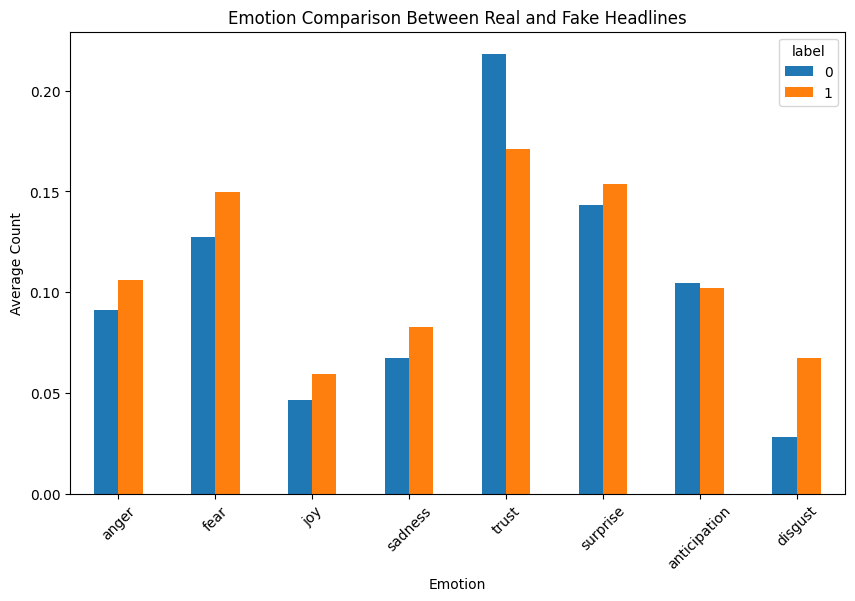

In [ ]:
# Visualize emotional differences between real and fake headlines
emotion_means.T.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Emotion Comparison Between Real and Fake Headlines')

plt.xlabel('Emotion')

plt.ylabel('Average Count')

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Convert cleaned headlines into TF-IDF feature vectors
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,
    min_df=5,
    ngram_range=(1,2)
)

# Create TF-IDF feature matrix
X = vectorizer.fit_transform(df['clean_title'])

# Create label vector
y = df['label']

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [ ]:
# Evaluate Logistic Regression model
print("Accuracy:", accuracy_score(y_test, lr_preds))

print(classification_report(y_test, lr_preds))

Accuracy: 0.9447661469933185
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4247
           1       0.96      0.94      0.95      4733

    accuracy                           0.94      8980
   macro avg       0.94      0.95      0.94      8980
weighted avg       0.94      0.94      0.94      8980



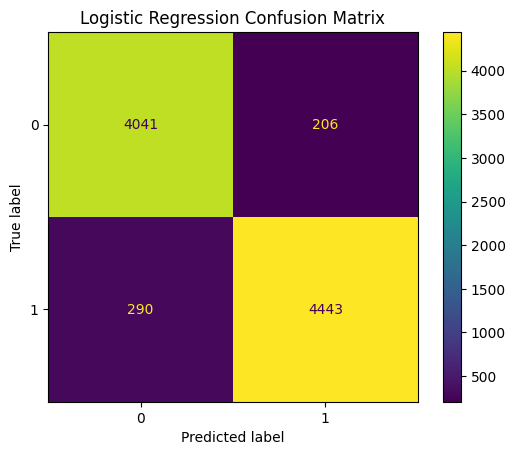

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, lr_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [ ]:
# Train Naive Bayes classifier
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)

In [ ]:
# Evaluate Naive Bayes model
print("Accuracy:", accuracy_score(y_test, nb_preds))

print(classification_report(y_test, nb_preds))

Accuracy: 0.9403118040089087
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      4247
           1       0.94      0.95      0.94      4733

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



In [ ]:
# Get feature names from TF-IDF vectorizer
feature_names = vectorizer.get_feature_names_out()

# Extract Logistic Regression coefficients
coefficients = lr_model.coef_[0]

# Identify strongest fake and real headline indicators
top_fake = coefficients.argsort()[-20:]
top_real = coefficients.argsort()[:20]

In [ ]:
# Extract Logistic Regression coefficients
print("Top Fake Indicators:\n")

for i in reversed(top_fake):
    print(feature_names[i], coefficients[i])

Top Fake Indicators:

video 19.98809633553062
watch 8.868830233191229
breaking 8.11577853786389
hillary 7.938985606082914
gop 7.368317778873072
tweets 4.834379379752839
obamas 4.7853350591995945
muslim 4.504778983411218
hillarys 4.463803898877227
america 4.3633201197496465
details 4.0335064123915245
racist 4.01064120855363
wow 3.8823014826301567
black 3.8335292355836326
president trump 3.7445817640414205
hes 3.591428822247974
isis 3.516609385840329
heres 3.514665139853791
donald 3.409093551573653
shocking 3.1311331420459294


In [ ]:
# Print strongest real headline indicators
print("\nTop Real Indicators:\n")

for i in top_real:
    print(feature_names[i], coefficients[i])


Top Real Indicators:

says -7.944423785814904
factbox -5.682099004711217
senate -4.132250049985723
china -3.986912060003281
house -3.7207561857174944
talks -3.7017620620886897
brexit -3.6952809145198193
pm -3.686767208094311
urges -3.626167890500515
eu -3.4769547652499835
lawmakers -3.46562288424791
seeks -3.410304946128601
south -3.27366117257322
minister -3.2361487309796484
german -3.2116299405027027
myanmar -3.189700927731734
tax -3.176391317647019
seek -3.175672606164964
probe -3.1648413336019137
turkey -3.1592135563299792
